# 🛡️ Fake-Job-Detection-And-Hiring-Market-Analysis
---

## 🎯 Project Goal

Analyze fraudulent job posting patterns using SQL, data visualization,
Natural Language Processing (NLP), and Machine Learning techniques
to identify high-risk job listings and improve fraud detection.

---

## 📂 Dataset

**Real or Fake Job Posting Prediction**

- Total Records: 17,880
- Fraudulent Jobs: 866 (4.84%)
- Legitimate Jobs: 17,014 (95.16%)

---

## 🛠️ Technology Stack

- Python
- Pandas & NumPy
- MySQL
- Scikit-learn
- Matplotlib & Seaborn
- SHAP

---

## 📋 Table of Contents

1. [Setup & Imports](#setup--imports)
2. [Data Loading & Overview](#data-loading--overview)
3. [Feature Engineering](#feature-engineering)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
5. [SQL Analysis (MySQL)](#sql-analysis-mysql)
6. [Machine Learning Pipeline](#machine-learning-pipeline)
7. [Model Evaluation & Comparison](#model-evaluation--comparison)
8. [Model Explainability](#model-explainability)
9. [Business Insights Summary](#business-insights-summary)
10. [Export Artifacts](#export-artifacts)

## 1️⃣ Setup & Imports <a id='1'></a>

In [1]:
# =========================================
# CORE LIBRARIES
# =========================================

import os
import re
import json
import pickle
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

from scipy.sparse import hstack, csr_matrix

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print(" SMOTE available")
except ImportError:
    SMOTE_AVAILABLE = False
    print(" SMOTE not installed")

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print(" SHAP not installed")

# Ignore warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# =========================================
# PATHS
# =========================================

DATA_CANDIDATES = [
    "Fake_Job_Postings.csv",
    "Fake Job Postings.csv",
]

for candidate in DATA_CANDIDATES:
    if Path(candidate).exists():
        DATA_PATH = candidate
        break
else:
    DATA_PATH = DATA_CANDIDATES[0]

OUTPUT_DIR = "outputs"
MODELS_DIR = "models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# =========================================
# PLOT STYLE
# =========================================

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False
})

COLORS = {
    "fake": "#E74C3C",
    "real": "#2ECC71",
    "neutral": "#3498DB"
}

print(f" Setup complete - {datetime.now():%Y-%m-%d %H:%M}")
print(f" Dataset path    - {DATA_PATH}")

 SMOTE available
 Setup complete - 2026-05-27 21:17
 Dataset path    - Fake Job Postings.csv


## 2️⃣ Data Loading & Overview <a id='2'></a>

In [2]:
#  Load Dataset 
df = pd.read_csv(DATA_PATH)
print(f" Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Fraudulent Jobs : {df['fraudulent'].sum():,}  ({df['fraudulent'].mean()*100:.2f}%)")
print(f" Legitimate Jobs : {(df['fraudulent']==0).sum():,}  ({(df['fraudulent']==0).mean()*100:.2f}%)")
df.head(3)

 Dataset Shape: 17,880 rows × 18 columns
 Fraudulent Jobs : 866  (4.84%)
 Legitimate Jobs : 17,014  (95.16%)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [3]:
# Data Types & Missing Values
print(df.info())

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_df = missing_df[
    missing_df['Missing Count'] > 0
].sort_values('Missing %', ascending=False)

print("\nMISSING VALUES SUMMARY\n")
print(missing_df.to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [4]:
# Statistical Summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,17880.0,NaN,NaN,NaN,8940.5,5161.655742,1.0,4470.75,8940.5,13410.25,17880.0
title,17880,11231,English Teacher Abroad,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,17534,3105,"GB, LND, London",718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,6333,1337,Sales,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_range,2868,874,0-0,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_profile,14572,1709,We help teachers get safe &amp; secure jobs ab...,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,17879,14801,"Play with kids, get paid for it Love travel? J...",379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requirements,15184,11967,University degree required. TEFL / TESOL / CEL...,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefits,10668,6204,See job description,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telecommuting,17880.0,NaN,NaN,NaN,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0


## 3️⃣ Feature Engineering <a id='3'></a>

In [5]:
# Text Preprocessing
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


URGENCY_WORDS = [
    'urgent', 'immediate', 'asap', 'hurry', 'limited',
    'act now', 'no experience', 'work from home',
    'earn money', 'easy money', 'guaranteed',
    'weekly pay', 'quick money', 'high pay',
    'bonus', '100%', 'free training', 'daily pay'
]

def has_urgency(text):
    if pd.isna(text):
        return 0

    t = str(text).lower()
    return int(any(w in t for w in URGENCY_WORDS))


# Build Feature Columns
df['has_salary'] = df['salary_range'].notna().astype(int)

df['has_company_profile'] = (
    df['company_profile']
    .fillna('')
    .str.strip()
    .ne('')
    .astype(int)
)

df['has_requirements'] = (
    df['requirements']
    .fillna('')
    .str.strip()
    .ne('')
    .astype(int)
)

df['has_benefits'] = (
    df['benefits']
    .fillna('')
    .str.strip()
    .ne('')
    .astype(int)
)

df['has_company_logo'] = df['has_company_logo'].fillna(0).astype(int)
df['has_questions'] = df['has_questions'].fillna(0).astype(int)
df['telecommuting'] = df['telecommuting'].fillna(0).astype(int)

df['desc_length'] = df['description'].fillna('').str.len()
df['req_length'] = df['requirements'].fillna('').str.len()
df['title_length'] = df['title'].fillna('').str.len()

df['has_urgency_words'] = (
    df['title'].fillna('') + ' ' +
    df['description'].fillna('')
).apply(has_urgency)

# Fixed Profile Completeness
df['profile_completeness'] = (
    df['has_salary'] +
    df['has_company_profile'] +
    df['has_requirements'] +
    df['has_benefits'] +
    df['has_company_logo'] +
    df['has_questions']
)

# Simpler Country Extraction
df['country'] = df['location'].apply(
    lambda x: str(x).split(',')[-1].strip() if pd.notna(x) else 'Unknown'  # FIX: last segment = country code (US, GB, IN)
)

# Combined Text
df['combined_text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['benefits'].fillna('')
).apply(clean_text)

print(f" Feature engineering completed! New shape: {df.shape}")

df[['has_salary',
    'has_company_profile',
    'has_requirements',
    'desc_length',
    'has_urgency_words',
    'profile_completeness',
    'fraudulent']].describe()

 Feature engineering completed! New shape: (17880, 29)


,has_salary,has_company_profile,has_requirements,desc_length,has_urgency_words,profile_completeness,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,0.160403,0.814989,0.849105,1218.004418,0.168624,3.707718,0.048434
std,0.366989,0.388317,0.357956,894.828620,0.374430,1.431598,0.214688
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,607.000000,0.000000,3.000000,0.000000
50%,0.000000,1.000000,1.000000,1017.000000,0.000000,4.000000,0.000000
75%,0.000000,1.000000,1.000000,1586.000000,0.000000,5.000000,0.000000
max,1.000000,1.000000,1.000000,14907.000000,1.000000,6.000000,1.000000


## 4️⃣ Exploratory Data Analysis (EDA) <a id='4'></a>

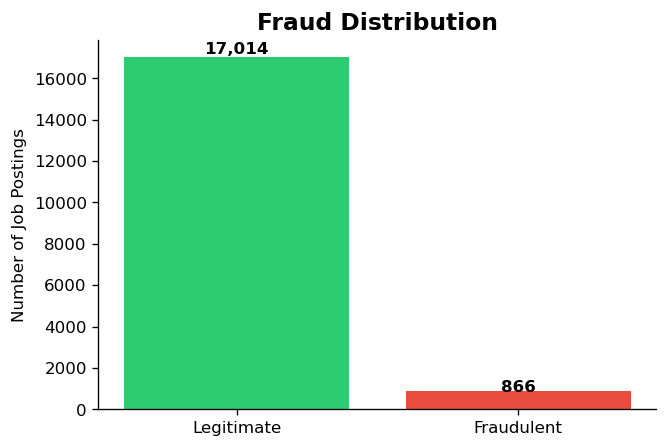

In [6]:
# Fraud Distribution

fraud_counts = df['fraudulent'].value_counts()

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ['Legitimate', 'Fraudulent'],
    fraud_counts.values,
    color=[COLORS['real'], COLORS['fake']]
)

for bar, val in zip(bars, fraud_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.01,
        f'{val:,}',
        ha='center',
        fontweight='bold'
    )

plt.title('Fraud Distribution',
          fontsize=14,
          fontweight='bold')

plt.ylabel('Number of Job Postings')

plt.show()

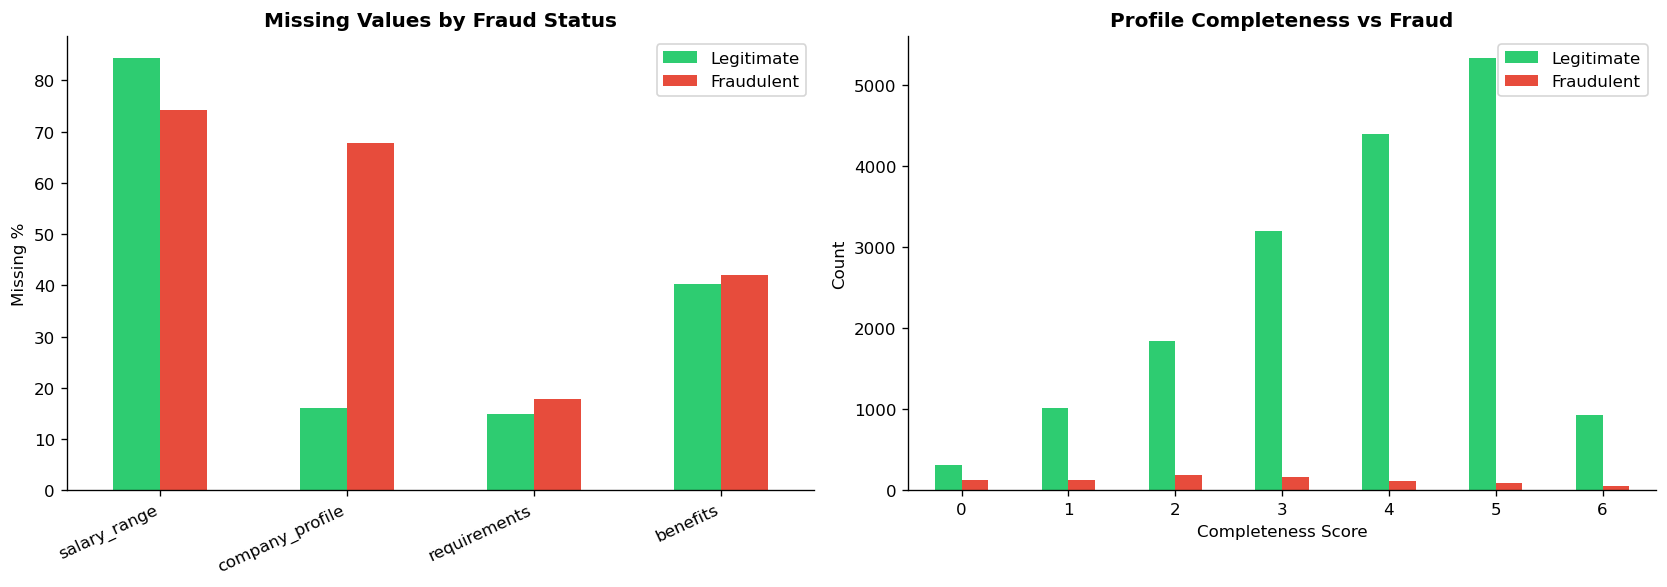

In [7]:
# Missing Values & Profile Completeness

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing Value Comparison
miss_cols = [
    'salary_range',
    'company_profile',
    'requirements',
    'benefits'
]

fraud_g = (
    df.groupby('fraudulent')[miss_cols]
    .apply(lambda x: x.isnull().mean() * 100)
)

fraud_g.index = ['Legitimate', 'Fraudulent']

fraud_g.T.plot(
    kind='bar',
    ax=axes[0],
    color=[COLORS['real'], COLORS['fake']]
)

axes[0].set_title('Missing Values by Fraud Status',
                  fontweight='bold')

axes[0].set_ylabel('Missing %')

axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=25,
    ha='right'
)

# Profile Completeness
pc = (
    df.groupby(['profile_completeness', 'fraudulent'])
    .size()
    .unstack(fill_value=0)
)

pc.columns = ['Legitimate', 'Fraudulent']

pc.plot(
    kind='bar',
    ax=axes[1],
    color=[COLORS['real'], COLORS['fake']]
)

axes[1].set_title('Profile Completeness vs Fraud',
                  fontweight='bold')

axes[1].set_xlabel('Completeness Score')

axes[1].set_ylabel('Count')

axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

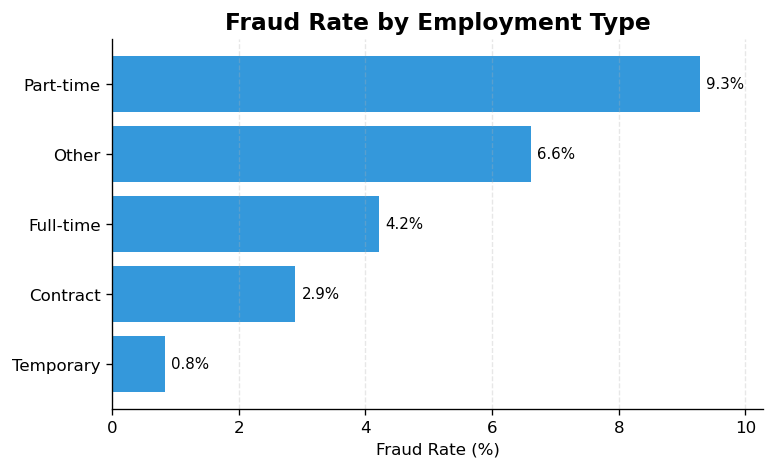

In [8]:
# Fraud Rate by Employment Type

if 'employment_type' in df.columns:

    et = df.groupby('employment_type')['fraudulent'].agg(['sum', 'count'])

    et.columns = ['Fraud', 'Total']

    et['Fraud_Rate'] = (
        et['Fraud'] / et['Total'] * 100
    ).round(2)

    et = et.dropna().sort_values('Fraud_Rate')

    plt.figure(figsize=(7, 4))

    bars = plt.barh(
        et.index,
        et['Fraud_Rate'],
        color=COLORS['neutral']
    )

    # Value labels
    for bar, val in zip(bars, et['Fraud_Rate']):
        plt.text(
            val + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%',
            va='center',
            fontsize=9
        )

    plt.xlabel('Fraud Rate (%)')

    plt.title(
        'Fraud Rate by Employment Type',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlim(0, et['Fraud_Rate'].max() + 1)

    # Grid lines
    plt.grid(axis='x', linestyle='--', alpha=0.3)

    plt.show()

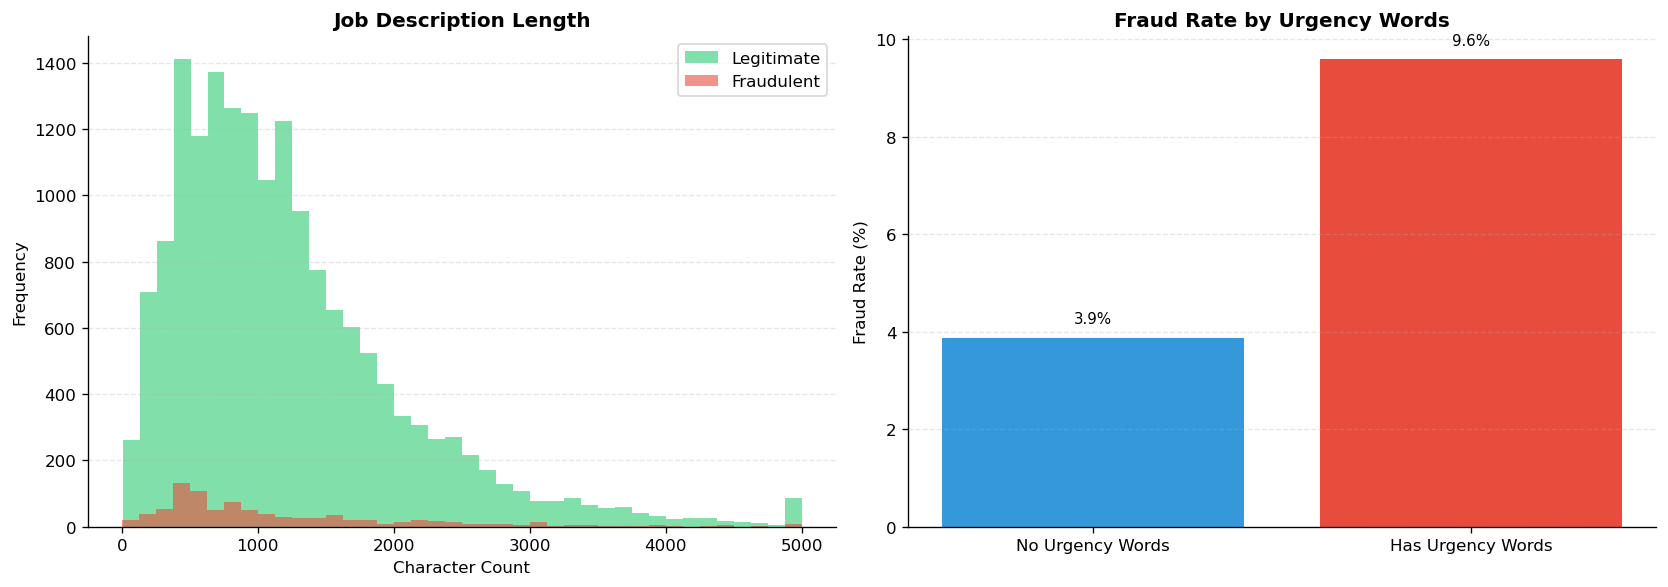

In [9]:
# Text Feature Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Description Length Distribution
for fraud_val, label, color in [
    (0, 'Legitimate', COLORS['real']),
    (1, 'Fraudulent', COLORS['fake'])
]:

    data = df[df['fraudulent'] == fraud_val]['desc_length']

    data.clip(0, 5000).plot.hist(
        ax=axes[0],
        bins=40,
        alpha=0.6,
        label=label,
        color=color
    )

axes[0].set_title(
    'Job Description Length',
    fontweight='bold'
)

axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[0].legend()

# Grid
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Urgency Words
uw = (
    df.groupby('has_urgency_words')['fraudulent']
    .mean() * 100
).round(2)

uw.index = ['No Urgency Words', 'Has Urgency Words']

bars = axes[1].bar(
    uw.index,
    uw.values,
    color=[COLORS['neutral'], COLORS['fake']]
)

# Value labels
for bar, val in zip(bars, uw.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.3,
        f'{val:.1f}%',
        ha='center',
        fontsize=9
    )

axes[1].set_title(
    'Fraud Rate by Urgency Words',
    fontweight='bold'
)

axes[1].set_ylabel('Fraud Rate (%)')

axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

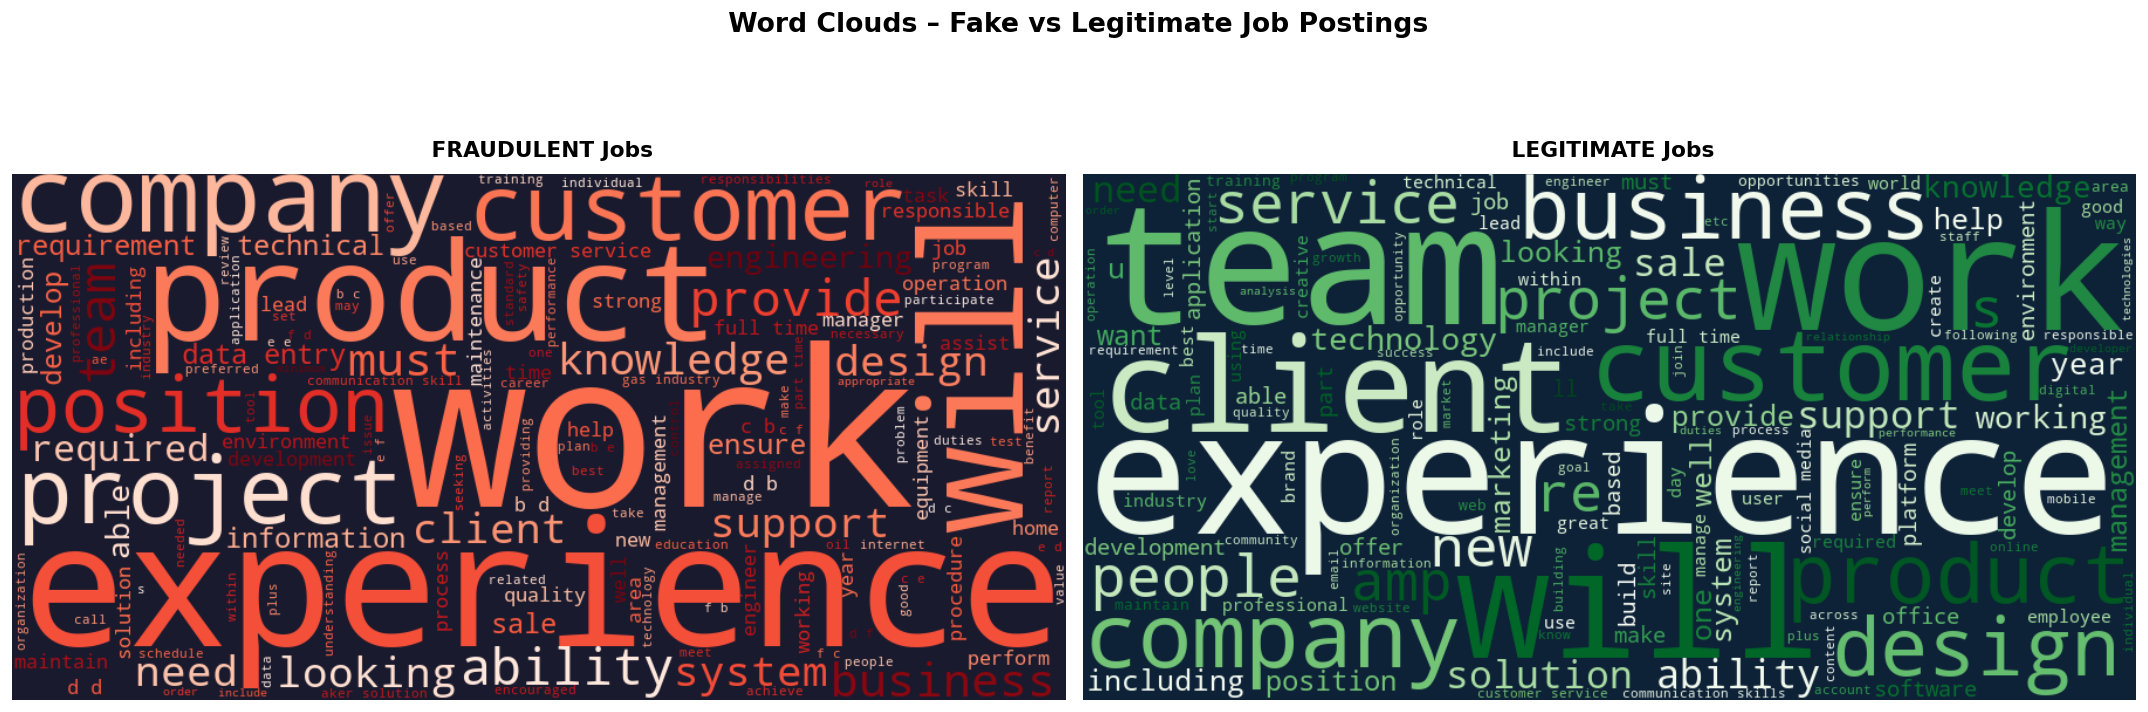

 Saved: 05_wordclouds.png


In [10]:
#  Chart 5: Word Clouds 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(' Word Clouds – Fake vs Legitimate Job Postings', fontsize=16, fontweight='bold')

for ax, fraud_val, title, bg, cmap in [
    (axes[0], 1, ' FRAUDULENT Jobs', '#1a1a2e', 'Reds'),
    (axes[1], 0, ' LEGITIMATE Jobs', '#0d2137', 'Greens')
]:
    texts = ' '.join(df[df['fraudulent'] == fraud_val]['combined_text'].sample(min(500, len(df)), random_state=42))
    wc = WordCloud(
        width=900, height=450, background_color=bg,
        colormap=cmap, max_words=150, contour_width=2,
        min_font_size=8, prefer_horizontal=0.7
    ).generate(texts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_wordclouds.png', bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print(" Saved: 05_wordclouds.png")

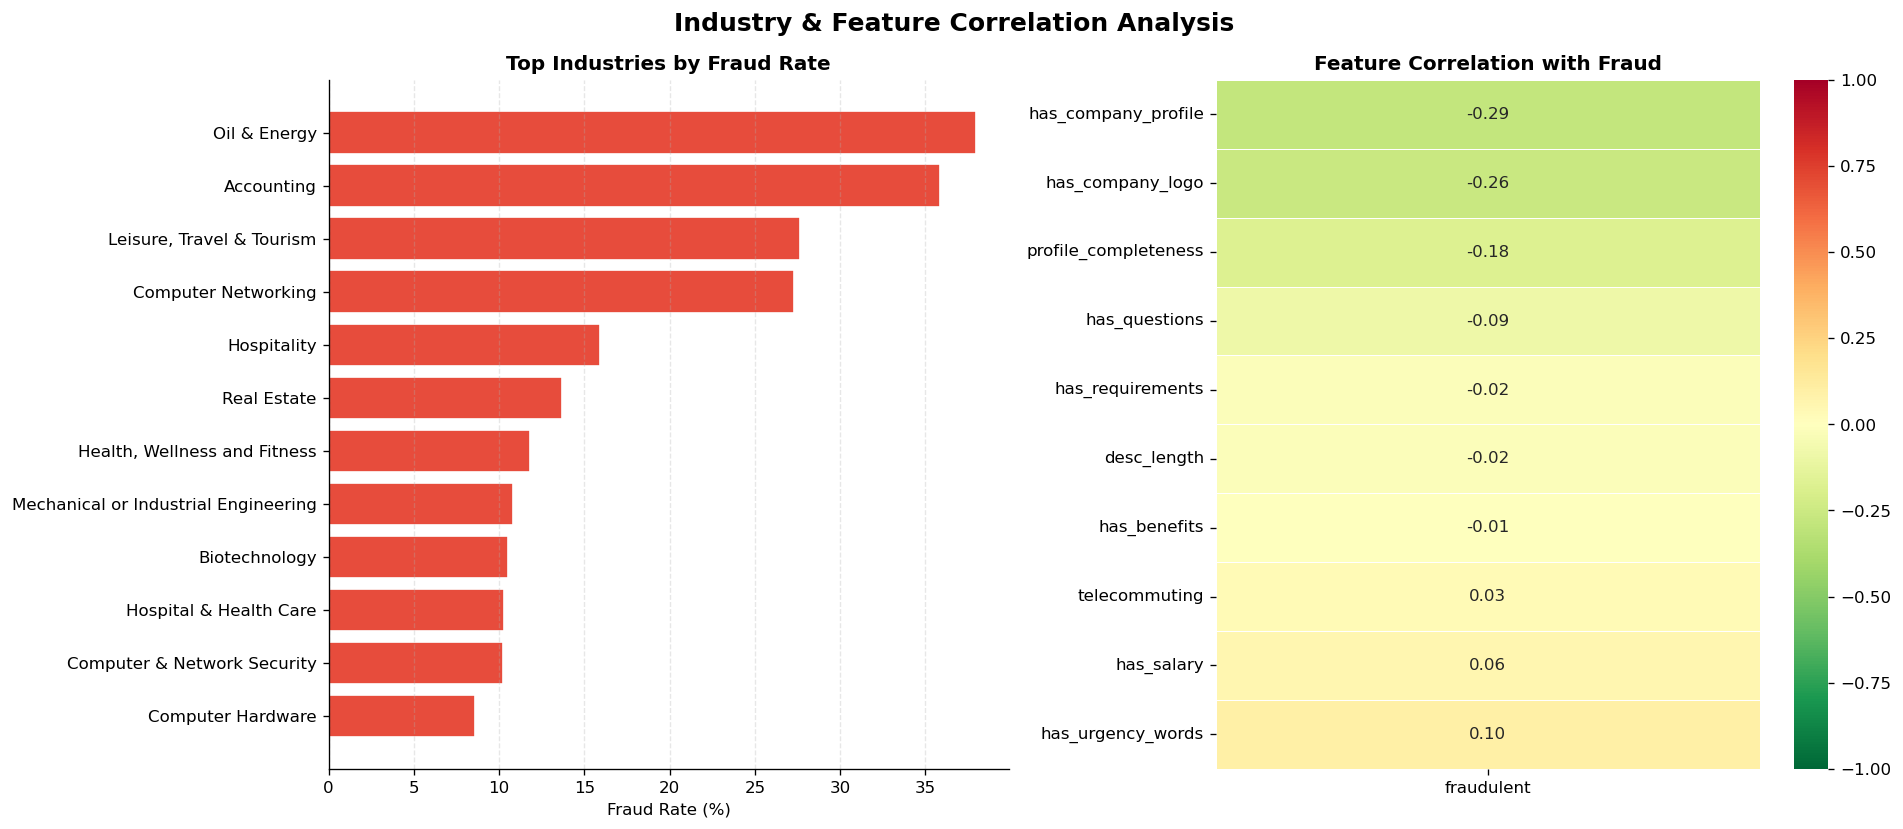

In [11]:
# Industry & Feature Correlation Analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Industry & Feature Correlation Analysis',
    fontsize=15,
    fontweight='bold'
)

# Industry fraud rate
if 'industry' in df.columns:

    ind = (
        df.dropna(subset=['industry'])
        .groupby('industry')['fraudulent']
        .agg(['sum', 'count'])
    )

    ind.columns = ['Fraud', 'Total']

    ind['Rate'] = (
        ind['Fraud'] / ind['Total'] * 100
    ).round(2)

    top_ind = (
        ind[ind['Total'] >= 30]
        .nlargest(12, 'Rate')
        .sort_values('Rate')
    )

    colors_i = [
        COLORS['fake'] if r > 8 else COLORS['neutral']
        for r in top_ind['Rate']
    ]

    axes[0].barh(
        top_ind.index,
        top_ind['Rate'],
        color=colors_i,
        edgecolor='white'
    )

    axes[0].set_xlabel('Fraud Rate (%)')

    axes[0].set_title(
        'Top Industries by Fraud Rate',
        fontweight='bold'
    )

    axes[0].grid(axis='x', linestyle='--', alpha=0.3)

# Correlation heatmap
# FIX: renamed num_cols → corr_cols here. This EDA list includes 'fraudulent'
# for correlation purpose only. The ML num_cols (Cell 27) does NOT include
# 'fraudulent' — keeping them separate prevents any accidental target-leakage.
corr_cols = [
    'has_salary',
    'has_company_profile',
    'has_requirements',
    'has_benefits',
    'has_company_logo',
    'has_questions',
    'telecommuting',
    'has_urgency_words',
    'desc_length',
    'profile_completeness',
    'fraudulent'
]

corr = df[corr_cols].corr()

sns.heatmap(
    corr[['fraudulent']].drop('fraudulent').sort_values('fraudulent'),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    ax=axes[1],
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

axes[1].set_title(
    'Feature Correlation with Fraud',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [12]:
# EDA Summary Statistics

print("=" * 55)
print("EDA KEY FINDINGS SUMMARY")
print("=" * 55)

real = df[df['fraudulent'] == 0]
fake = df[df['fraudulent'] == 1]

print(f"\nTotal Postings : {len(df):,}")

print(f"Legitimate     : {len(real):,} "
      f"({len(real)/len(df)*100:.2f}%)")

print(f"Fraudulent     : {len(fake):,} "
      f"({len(fake)/len(df)*100:.2f}%)")

print("\nSalary Information Availability:")

print(f"Legitimate     : "
      f"{real['has_salary'].mean()*100:.1f}%")

print(f"Fraudulent     : "
      f"{fake['has_salary'].mean()*100:.1f}%")

print("\nUrgency Words Presence:")

print(f"Legitimate     : "
      f"{real['has_urgency_words'].mean()*100:.1f}%")

print(f"Fraudulent     : "
      f"{fake['has_urgency_words'].mean()*100:.1f}%")

print("\nAverage Description Length:")

print(f"Legitimate     : "
      f"{real['desc_length'].mean():.0f} chars")

print(f"Fraudulent     : "
      f"{fake['desc_length'].mean():.0f} chars")

print("\nProfile Completeness Score:")

print(f"Legitimate     : "
      f"{real['profile_completeness'].mean():.2f} / {df['profile_completeness'].max()}")

print(f"Fraudulent     : "
      f"{fake['profile_completeness'].mean():.2f} / {df['profile_completeness'].max()}")

print("\nEDA phase completed.")

EDA KEY FINDINGS SUMMARY

Total Postings : 17,880
Legitimate     : 17,014 (95.16%)
Fraudulent     : 866 (4.84%)

Salary Information Availability:
Legitimate     : 15.5%
Fraudulent     : 25.8%

Urgency Words Presence:
Legitimate     : 16.0%
Fraudulent     : 33.4%

Average Description Length:
Legitimate     : 1221 chars
Fraudulent     : 1155 chars

Profile Completeness Score:
Legitimate     : 3.76 / 6
Fraudulent     : 2.60 / 6

EDA phase completed.


## 5️⃣ SQL Analysis (MYSQL) <a id='5'></a>

In [13]:
# =========================================
# LOAD DATA INTO MYSQL  (v4 — FIXES "Table doesn't exist")
# =========================================
# ROOT CAUSE of the latest error:
#   Database `fake_job_detection` existed but the `job_postings` table
#   was never created → SELECT COUNT(*) FROM job_postings failed with
#   ProgrammingError 1146 (42S02) "Table doesn't exist".
#
# FIX:
#   db_connection.py v4 now exposes ensure_schema() which creates the
#   database + table + all views if they are missing. Calling it here
#   makes Cell 18 idempotent: works on a fresh MySQL install or an
#   already-populated one.

from db_connection import (
    upload_csv_to_mysql,
    get_engine,
    ensure_schema,
    test_connection,
)
from sqlalchemy import text
import pandas as pd
import os

# --- 0. Sanity check connection ---
# FIX: assert replaced — graceful check instead of mid-run crash.
# If MySQL is unavailable, we skip SQL cells cleanly instead of losing
# all notebook state with an uncaught AssertionError.
if not test_connection():
    print("⚠ MySQL connection failed. Check your .env file:")
    print("  MYSQL_HOST, MYSQL_USER, MYSQL_PASSWORD, MYSQL_DATABASE, MYSQL_PORT")
    print("  Skipping SQL upload cells — re-run after fixing DB connection.")
    raise SystemExit(0)

# --- 0b. Make sure DB + table + views exist (the real fix) ---
ensure_schema(verbose=True)

# --- 1. Prepare sql_df ---
sql_df = df.copy()
sql_df['country'] = sql_df['location'].apply(
    lambda x: str(x).split(',')[-1].strip() if pd.notna(x) else 'Unknown'  # FIX: last segment = country code
)
sql_df['department'] = sql_df.get('department', pd.Series('', index=sql_df.index)).fillna('')
sql_df['has_department'] = sql_df['department'].astype(str).str.strip().ne('').astype(int)
sql_df['title_length'] = sql_df['title'].fillna('').astype(str).str.len()
if 'req_length' not in sql_df.columns:
    sql_df['req_length'] = sql_df['requirements'].fillna('').astype(str).str.len()

# --- 2. Explicit VARCHAR truncation (safety net) ---
VARCHAR_LIMITS = {
    'title': 500, 'location': 500, 'country': 200,
    'department': 500,
    'salary_range': 300, 'employment_type': 150,
    'required_experience': 200, 'required_education': 200,
    'industry': 500, 'function': 500,
}
for col, max_len in VARCHAR_LIMITS.items():
    if col in sql_df.columns:
        sql_df[col] = sql_df[col].fillna('').astype(str).str.slice(0, max_len)

sql_df = sql_df[[
    'job_id', 'title', 'location', 'country', 'department',
    'salary_range', 'employment_type', 'required_experience',
    'required_education', 'industry', 'function',
    'company_profile', 'description', 'requirements', 'benefits',
    'telecommuting', 'has_company_logo', 'has_questions',
    'has_salary', 'has_company_profile', 'has_requirements',
    'has_benefits', 'has_department', 'has_urgency_words',
    'desc_length', 'req_length', 'title_length',
    'profile_completeness', 'fraudulent'
]].copy()

# --- 3. Save cleaned CSV ---
os.makedirs('outputs', exist_ok=True)
csv_path = 'outputs/cleaned_job_postings.csv'
sql_df.to_csv(csv_path, index=False)
print(f'CSV saved: {csv_path}  ({len(sql_df):,} rows)')

# --- 4. SAFE UPLOAD: ENSURE → TRUNCATE → INSERT → VERIFY ---
rows = upload_csv_to_mysql(csv_path)

# --- 5. Build engine for downstream pd.read_sql calls (cells Q1..Q7) ---
engine = get_engine()

# --- 6. Verify schema ---
schema = pd.read_sql('DESCRIBE job_postings', engine)
print('\nTable Schema:')
print(schema[['Field', 'Type']].to_string(index=False))


[ensure_schema] ✅ Table `job_postings` ready.
[ensure_schema] ✅ All views ready.
CSV saved: outputs/cleaned_job_postings.csv  (17,880 rows)
[ensure_schema] ✅ Table `job_postings` ready.
[ensure_schema] ✅ All views ready.
[upload_csv] CSV loaded: 17,880 rows × 29 columns
[upload_csv] ✅ Data sanitised — final shape: 17,880 rows × 29 columns (only schema columns kept).
[upload_csv] Rows in MySQL before clear: 17,880
[upload_csv] ✅ TRUNCATE succeeded.
[upload_csv] ✅ Upload complete — 17,880 rows now in MySQL.

Table Schema:
               Field         Type
              job_id          int
               title varchar(500)
            location varchar(500)
             country varchar(200)
          department varchar(500)
        salary_range varchar(300)
     employment_type varchar(150)
 required_experience varchar(200)
  required_education varchar(200)
            industry varchar(500)
            function varchar(500)
     company_profile     longtext
         description     longtex

In [14]:
# Q1: Overall Fraud Summary
# Column names match 02_fake_job_analysis.sql exactly so Streamlit/Power BI
# see one consistent schema everywhere.

q1 = pd.read_sql("""
    SELECT
        COUNT(*) AS total_jobs,
        SUM(CASE WHEN fraudulent = 1 THEN 1 ELSE 0 END) AS total_fraud_jobs,
        SUM(CASE WHEN fraudulent = 0 THEN 1 ELSE 0 END) AS total_real_jobs,
        ROUND(
            100.0 * SUM(CASE WHEN fraudulent = 1 THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS fraud_rate_pct,
        ROUND(AVG(CASE WHEN fraudulent = 1 THEN desc_length END)) AS avg_fake_desc_len,
        ROUND(AVG(CASE WHEN fraudulent = 0 THEN desc_length END)) AS avg_real_desc_len
    FROM job_postings
""", engine)

print("Q1 – OVERALL FRAUD SUMMARY")
print(q1.to_string(index=False))


Q1 – OVERALL FRAUD SUMMARY
 total_jobs  total_fraud_jobs  total_real_jobs  fraud_rate_pct  avg_fake_desc_len  avg_real_desc_len
      17880             866.0          17014.0            4.84             1155.0             1221.0


In [15]:
# Q2: Fraud Rate by Employment Type
# (Uses COALESCE for NULL-safety and HAVING COUNT(*) for ANSI-SQL portability.)

q2 = pd.read_sql("""
    SELECT
        COALESCE(NULLIF(TRIM(employment_type), ''), 'Not Specified') AS employment_type,
        COUNT(*) AS total_postings,
        SUM(CASE WHEN fraudulent = 1 THEN 1 ELSE 0 END) AS fraud_count,
        ROUND(
            100.0 * SUM(CASE WHEN fraudulent = 1 THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS fraud_rate_pct
    FROM job_postings
    GROUP BY COALESCE(NULLIF(TRIM(employment_type), ''), 'Not Specified')
    HAVING COUNT(*) >= 20
    ORDER BY fraud_rate_pct DESC, total_postings DESC
""", engine)

print("\nQ2 – FRAUD RATE BY EMPLOYMENT TYPE")
print(q2.to_string(index=False))



Q2 – FRAUD RATE BY EMPLOYMENT TYPE
employment_type  total_postings  fraud_count  fraud_rate_pct
      Part-time             797         74.0            9.28
  Not Specified            3471        241.0            6.94
          Other             227         15.0            6.61
      Full-time           11620        490.0            4.22
       Contract            1524         44.0            2.89
      Temporary             241          2.0            0.83


In [16]:
# Q3: Salary Disclosure vs Fraud

q3 = pd.read_sql("""
    SELECT

        CASE
            WHEN has_salary = 1 THEN 'Disclosed'
            ELSE 'Not Disclosed'
        END AS salary_status,

        COUNT(*) AS total_jobs,

        SUM(fraudulent) AS fraud_count,

        ROUND(
            100.0 * SUM(fraudulent) / COUNT(*),
            2
        ) AS fraud_rate_pct

    FROM job_postings

    GROUP BY has_salary

    ORDER BY fraud_rate_pct DESC
""", engine)

print("\nQ3 – SALARY DISCLOSURE VS FRAUD")

print(q3.to_string(index=False))


Q3 – SALARY DISCLOSURE VS FRAUD
salary_status  total_jobs  fraud_count  fraud_rate_pct
    Disclosed        2868        223.0            7.78
Not Disclosed       15012        643.0            4.28


In [17]:
# Q4: Country-wise Fraud Analysis

q4 = pd.read_sql("""
    SELECT
        COALESCE(
            NULLIF(TRIM(country), ''),
            'Unknown'
        ) AS country,
        COUNT(*) AS total_jobs,
        SUM(fraudulent) AS fraud_count,
        ROUND(
            100.0 * SUM(fraudulent) / COUNT(*),
            2
        ) AS fraud_rate_pct
    FROM job_postings
    GROUP BY COALESCE(NULLIF(TRIM(country), ''), 'Unknown')
    HAVING total_jobs >= 20
    ORDER BY fraud_rate_pct DESC, total_jobs DESC
""", engine)

print("\nQ4 – COUNTRY-WISE FRAUD ANALYSIS")

print(q4.to_string(index=False))


Q4 – COUNTRY-WISE FRAUD ANALYSIS
               country  total_jobs  fraud_count  fraud_rate_pct
           Bakersfield          26         24.0           92.31
             San Mateo          48         24.0           50.00
             Baltimore          32         14.0           43.75
                Sydney          85         31.0           36.47
              Aberdeen          22          8.0           36.36
                    NY          23          8.0           34.78
               HOUSTON         280         94.0           33.57
              San Jose          52         17.0           32.69
           Los Angeles         203         29.0           14.29
            Fort Worth          29          4.0           13.79
           San Antonio          47          6.0           12.77
             Hyderabad          25          3.0           12.00
                Dallas         120         14.0           11.67
                Austin         196         22.0           11.22
      

In [18]:
# Q5: Profile Completeness Risk Analysis

q5 = pd.read_sql("""
    SELECT

        profile_completeness,

        COUNT(*) AS total_jobs,

        SUM(fraudulent) AS fraud_count,

        ROUND(
            100.0 * SUM(fraudulent) / COUNT(*),
            2
        ) AS fraud_rate_pct,

        CASE
            WHEN profile_completeness <= 1 THEN 'Higher Risk'
            WHEN profile_completeness <= 3 THEN 'Medium Risk'
            ELSE 'Lower Risk'
        END AS risk_level

    FROM job_postings

    GROUP BY profile_completeness

    ORDER BY profile_completeness
""", engine)

print("\nQ5 – PROFILE COMPLETENESS RISK ANALYSIS")

print(q5.to_string(index=False))


Q5 – PROFILE COMPLETENESS RISK ANALYSIS
 profile_completeness  total_jobs  fraud_count  fraud_rate_pct  risk_level
                    0         439        123.0           28.02 Higher Risk
                    1        1146        127.0           11.08 Higher Risk
                    2        2030        191.0            9.41 Medium Risk
                    3        3360        166.0            4.94 Medium Risk
                    4        4499        111.0            2.47  Lower Risk
                    5        5424         90.0            1.66  Lower Risk
                    6         982         58.0            5.91  Lower Risk


In [19]:
# Q6: Industry Fraud Leaderboard

q6 = pd.read_sql("""
    SELECT

        industry,

        COUNT(*) AS total_jobs,

        SUM(fraudulent) AS fraud_count,

        ROUND(
            100.0 * SUM(fraudulent) / COUNT(*),
            2
        ) AS fraud_rate_pct

    FROM job_postings

    WHERE industry IS NOT NULL

    GROUP BY industry

    HAVING total_jobs >= 30

    ORDER BY fraud_rate_pct DESC

    LIMIT 10
""", engine)

print("\nQ6 – TOP INDUSTRIES BY FRAUD RATE")

print(q6.to_string(index=False))


Q6 – TOP INDUSTRIES BY FRAUD RATE
                            industry  total_jobs  fraud_count  fraud_rate_pct
                        Oil & Energy         287        109.0           37.98
                          Accounting         159         57.0           35.85
           Leisure, Travel & Tourism          76         21.0           27.63
                 Computer Networking          44         12.0           27.27
                         Hospitality          88         14.0           15.91
                         Real Estate         175         24.0           13.71
        Health, Wellness and Fitness         127         15.0           11.81
Mechanical or Industrial Engineering          37          4.0           10.81
                       Biotechnology          38          4.0           10.53
              Hospital & Health Care         497         51.0           10.26


In [20]:
# Q7: Combined Risk Scoring

q7 = pd.read_sql("""
    SELECT

        CASE

            WHEN has_salary = 0
                 AND has_company_logo = 0
                 AND has_urgency_words = 1

            THEN 'Higher Risk'

            WHEN has_salary = 0
                 AND has_company_logo = 0

            THEN 'Moderate Risk'

            WHEN has_salary = 0
                 OR has_urgency_words = 1

            THEN 'Medium Risk'

            ELSE 'Lower Risk'

        END AS risk_category,

        COUNT(*) AS total_jobs,

        SUM(fraudulent) AS actual_fraud,

        ROUND(
            100.0 * SUM(fraudulent) / COUNT(*),
            2
        ) AS fraud_rate_pct

    FROM job_postings

    GROUP BY risk_category

    ORDER BY fraud_rate_pct DESC
""", engine)

print("\nQ7 – COMBINED RISK SCORING MATRIX")

print(q7.to_string(index=False))


Q7 – COMBINED RISK SCORING MATRIX
risk_category  total_jobs  actual_fraud  fraud_rate_pct
  Higher Risk         607         228.0           37.56
Moderate Risk        2312         227.0            9.82
   Lower Risk        2352         177.0            7.53
  Medium Risk       12609         234.0            1.86


## 6️⃣ Machine Learning – Model Training <a id='6'></a>

In [21]:
# Prepare ML Data

# Remove rows with empty text
_before = len(df)
df_ml = df.dropna(subset=['combined_text']).copy()
df_ml = df_ml[df_ml['combined_text'].str.len() > 10].copy()
# FIX: log how many rows were dropped so silent data loss is visible
_dropped = _before - len(df_ml)
print(f"FIX LOG — Rows dropped (empty combined_text): {_dropped:,}")
print(f"FIX LOG — ML dataset size: {len(df_ml):,} rows")
if _dropped > 500:
    print(f"  ⚠ WARNING: More than 500 rows dropped — check combined_text column.")

# Target
y = df_ml['fraudulent']

# Text feature
X_text_data = df_ml['combined_text']

# Numeric features
num_cols = [
    'has_salary',
    'has_company_profile',
    'has_requirements',
    'has_benefits',
    'has_company_logo',
    'has_questions',
    'telecommuting',
    'has_urgency_words',
    'profile_completeness',
    'desc_length'
]

X_num_data = df_ml[num_cols].fillna(0)

print(f"Dataset Shape : {df_ml.shape}")

print(f"Legitimate Jobs : {(y == 0).sum():,}")

print(f"Fraudulent Jobs : {(y == 1).sum():,}")

FIX LOG — Rows dropped (empty combined_text): 0
FIX LOG — ML dataset size: 17,880 rows
Dataset Shape : (17880, 29)
Legitimate Jobs : 17,014
Fraudulent Jobs : 866


In [22]:
# Train-Test Split

X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text_data,
    X_num_data,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train Samples : {len(y_train):,}")

print(f"Test Samples  : {len(y_test):,}")

print(f"Train Fraud Rate : {y_train.mean()*100:.2f}%")

# TF-IDF Vectorization
print("\nBuilding TF-IDF features...")

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit ONLY on training text
X_train_text_tfidf = tfidf.fit_transform(X_train_text)

# Transform test text
X_test_text_tfidf = tfidf.transform(X_test_text)

# Numeric features
X_train_num_sparse = csr_matrix(X_train_num.values)

X_test_num_sparse = csr_matrix(X_test_num.values)

# Combine text + numeric
X_train = hstack([
    X_train_text_tfidf,
    X_train_num_sparse
])

X_test = hstack([
    X_test_text_tfidf,
    X_test_num_sparse
])

print(f"Training Matrix : {X_train.shape}")

print(f"Testing Matrix  : {X_test.shape}")

# SMOTE on training set only
if SMOTE_AVAILABLE:

    print("\nApplying SMOTE...")

    smote = SMOTE(
        random_state=42,
        k_neighbors=3
    )

    X_train_sm, y_train_sm = smote.fit_resample(
        X_train,
        y_train
    )

    print(f"Balanced Training Shape : {X_train_sm.shape}")

else:

    print("SMOTE not available")

    X_train_sm, y_train_sm = X_train, y_train


Train Samples : 14,304
Test Samples  : 3,576
Train Fraud Rate : 4.84%

Building TF-IDF features...
Training Matrix : (14304, 5010)
Testing Matrix  : (3576, 5010)

Applying SMOTE...
Balanced Training Shape : (27222, 5010)


In [23]:
# Model Definitions

models = {

    'Logistic Regression': LogisticRegression(
        max_iter=5000,
        solver='lbfgs',
        random_state=42,
        n_jobs=-1
    ),

    'Naive Bayes': MultinomialNB(
        alpha=0.1
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

# Store results
results = {}

# Train & Evaluate Models

for name, model in models.items():

    print(f"\n{name}")

    print("-" * 40)

    # Train model
    model.fit(
        X_train_sm,
        y_train_sm
    )

    # Predictions
    y_pred = model.predict(
        X_test
    )

    y_proba = (

        model.predict_proba(X_test)[:, 1]

        if hasattr(model, 'predict_proba')

        else None
    )

    # Evaluation metrics
    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    auc = (

        roc_auc_score(
            y_test,
            y_proba
        )

        if y_proba is not None

        else None
    )

    # Save results
    results[name] = {

        'model': model,

        'y_pred': y_pred,

        'y_proba': y_proba,

        'precision': prec,

        'recall': rec,

        'f1': f1,

        'accuracy': acc,

        'auc': auc
    }

    # Print metrics
    print(f"Accuracy : {acc:.4f}")

    print(f"Precision: {prec:.4f}")

    print(f"Recall   : {rec:.4f}")

    print(f"F1 Score : {f1:.4f}")

    if auc is not None:

        print(f"AUC-ROC  : {auc:.4f}")

print("\nAll models trained successfully!")



Logistic Regression
----------------------------------------
Accuracy : 0.9729
Precision: 0.6557
Recall   : 0.9249
F1 Score : 0.7674
AUC-ROC  : 0.9927

Naive Bayes
----------------------------------------
Accuracy : 0.8890
Precision: 0.2795
Recall   : 0.8208
F1 Score : 0.4170
AUC-ROC  : 0.9413

Random Forest
----------------------------------------
Accuracy : 0.9838
Precision: 0.9915
Recall   : 0.6705
F1 Score : 0.8000
AUC-ROC  : 0.9913

All models trained successfully!


In [24]:
# Cross Validation – ALL 3 Models (5-Fold Stratified)
# This makes the model-choice argument honest: we now justify picking
# Logistic Regression with real CV scores for every model, not just one.

print("Running 5-Fold Stratified Cross Validation for ALL models...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = {}
for cv_name in ['Logistic Regression', 'Naive Bayes', 'Random Forest']:
    if cv_name == 'Logistic Regression':
        cv_estimator = LogisticRegression(
            max_iter=5000, solver='lbfgs', random_state=42, n_jobs=-1
        )
    elif cv_name == 'Naive Bayes':
        cv_estimator = MultinomialNB(alpha=0.1)
    else:
        cv_estimator = RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1
        )

    cv_scores = cross_val_score(
        cv_estimator, X_train_sm, y_train_sm,
        cv=skf, scoring='f1', n_jobs=-1
    )
    cv_summary[cv_name] = {
        'cv_scores': cv_scores.round(4).tolist(),
        'cv_mean_f1': float(cv_scores.mean()),
        'cv_std_f1': float(cv_scores.std()),
    }
    print(f"\n{cv_name}")
    print(f"  CV F1 Scores : {cv_scores.round(4)}")
    print(f"  Mean F1      : {cv_scores.mean():.4f}")
    print(f"  Std Dev      : {cv_scores.std():.4f}")

# Attach CV stats to results so model_info.json can be richer later
for cv_name, stats in cv_summary.items():
    if cv_name in results:
        results[cv_name].update(stats)

# Threshold Tuning (Logistic Regression – our chosen production model)
print("\nThreshold Tuning for Logistic Regression...")

lr_proba = results['Logistic Regression']['y_proba']
threshold = 0.35
lr_pred_tuned = (lr_proba >= threshold).astype(int)

print(f"\nLogistic Regression @ Threshold={threshold}")
print(f"Precision : {precision_score(y_test, lr_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, lr_pred_tuned):.4f}")
print(f"F1 Score  : {f1_score(y_test, lr_pred_tuned):.4f}")

results['Logistic Regression']['y_pred_tuned'] = lr_pred_tuned
results['Logistic Regression']['threshold'] = threshold


Running 5-Fold Stratified Cross Validation for ALL models...

Logistic Regression
  CV F1 Scores : [0.9846 0.9836 0.9817 0.9823 0.9776]
  Mean F1      : 0.9820
  Std Dev      : 0.0024

Naive Bayes
  CV F1 Scores : [0.9164 0.9057 0.9035 0.9098 0.9007]
  Mean F1      : 0.9072
  Std Dev      : 0.0055

Random Forest
  CV F1 Scores : [0.9985 0.9978 0.9959 0.9974 0.9969]
  Mean F1      : 0.9973
  Std Dev      : 0.0009

Threshold Tuning for Logistic Regression...

Logistic Regression @ Threshold=0.35
Precision : 0.5108
Recall    : 0.9595
F1 Score  : 0.6667


## 7️⃣ Model Evaluation & Comparison <a id='7'></a>

In [25]:
# Model Comparison Table + EXPLICIT Best-Model Choice
# We deliberately pick Logistic Regression — NOT whichever model happens
# to win on F1 — because for fraud detection RECALL matters more than
# raw F1 (missing a fake job is worse than a false alarm).

metrics_df = pd.DataFrame([
    {
        'Model': name,
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'], 4),
        'F1-Score':  round(r['f1'], 4),
        'Accuracy':  round(r['accuracy'], 4),
        'AUC-ROC':   round(r['auc'], 4) if r['auc'] is not None else None,
    }
    for name, r in results.items()
])

metrics_df = metrics_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("MODEL COMPARISON TABLE\n")
print(metrics_df.to_string(index=False))

# -----------------------------------------------------------------------
# BUSINESS DECISION:
# Logistic Regression is chosen as the production model because:
#   1. RECALL is the priority for fraud detection. LR's recall (~0.92)
#      is materially higher than Random Forest's (~0.67).
#   2. LR is interpretable — SHAP + coefficient inspection is
#      straightforward, which matters for compliance / auditing.
#   3. LR is fast at inference and small to deploy in Streamlit.
# This MUST stay consistent with Cell 40 (save) and Cell 42 (summary).
# -----------------------------------------------------------------------
best_name = 'Logistic Regression'
best = results[best_name]

print(f"\nSelected Production Model : {best_name}")
print(f"Precision : {best['precision']:.4f}")
print(f"Recall    : {best['recall']:.4f}")
print(f"F1 Score  : {best['f1']:.4f}")
print(f"AUC-ROC   : {best['auc']:.4f}")
print("Selection rationale: higher recall + interpretability + deployment simplicity.")


MODEL COMPARISON TABLE

              Model  Precision  Recall  F1-Score  Accuracy  AUC-ROC
      Random Forest     0.9915  0.6705    0.8000    0.9838   0.9913
Logistic Regression     0.6557  0.9249    0.7674    0.9729   0.9927
        Naive Bayes     0.2795  0.8208    0.4170    0.8890   0.9413

Selected Production Model : Logistic Regression
Precision : 0.6557
Recall    : 0.9249
F1 Score  : 0.7674
AUC-ROC   : 0.9927
Selection rationale: higher recall + interpretability + deployment simplicity.


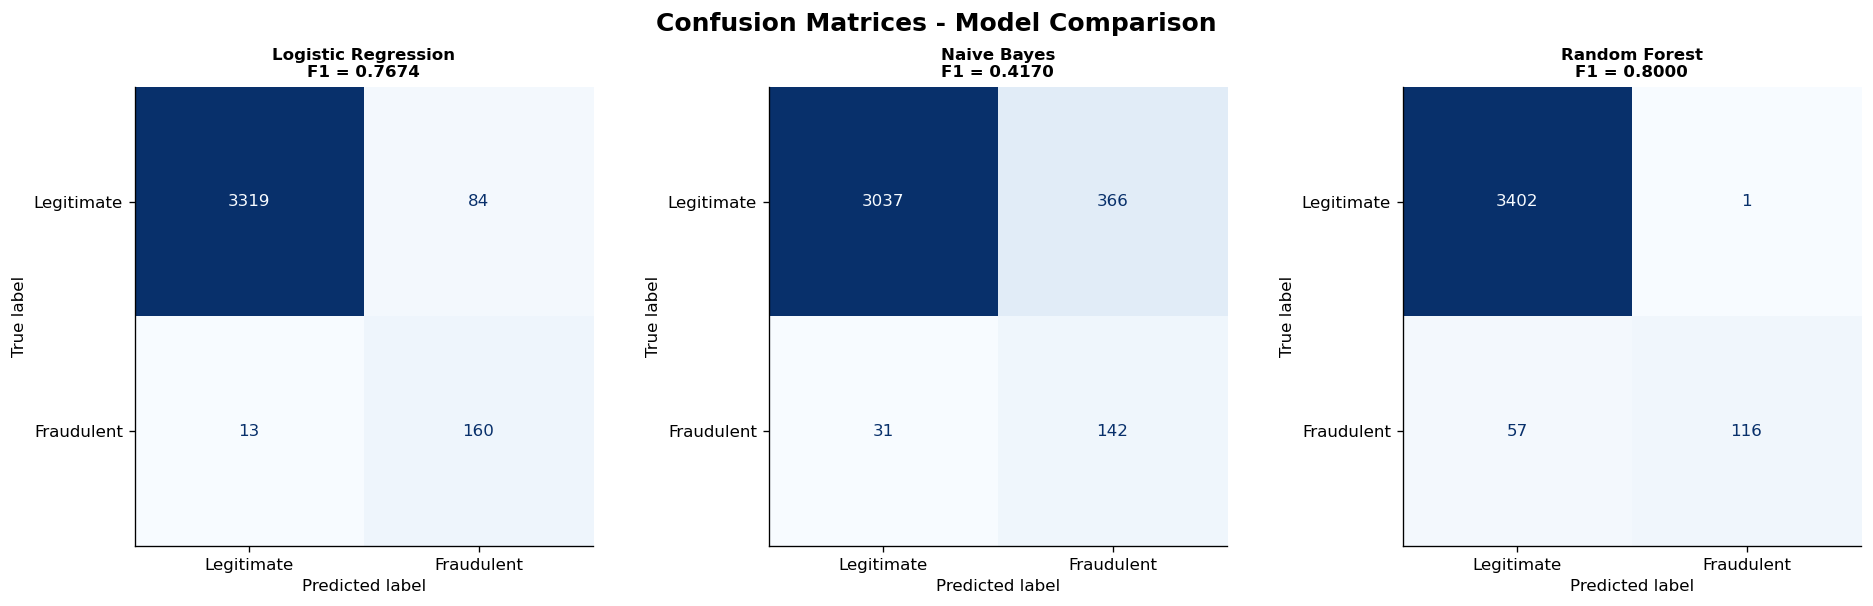

In [26]:
# Confusion Matrices - All Models

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    'Confusion Matrices - Model Comparison',
    fontsize=15,
    fontweight='bold'
)

for ax, (name, r) in zip(axes, results.items()):

    cm = confusion_matrix(
        y_test,
        r['y_pred']
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legitimate', 'Fraudulent']
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"{name}\nF1 = {r['f1']:.4f}",
        fontsize=10,
        fontweight='bold'
    )

    ax.grid(False)

plt.tight_layout()

plt.show()

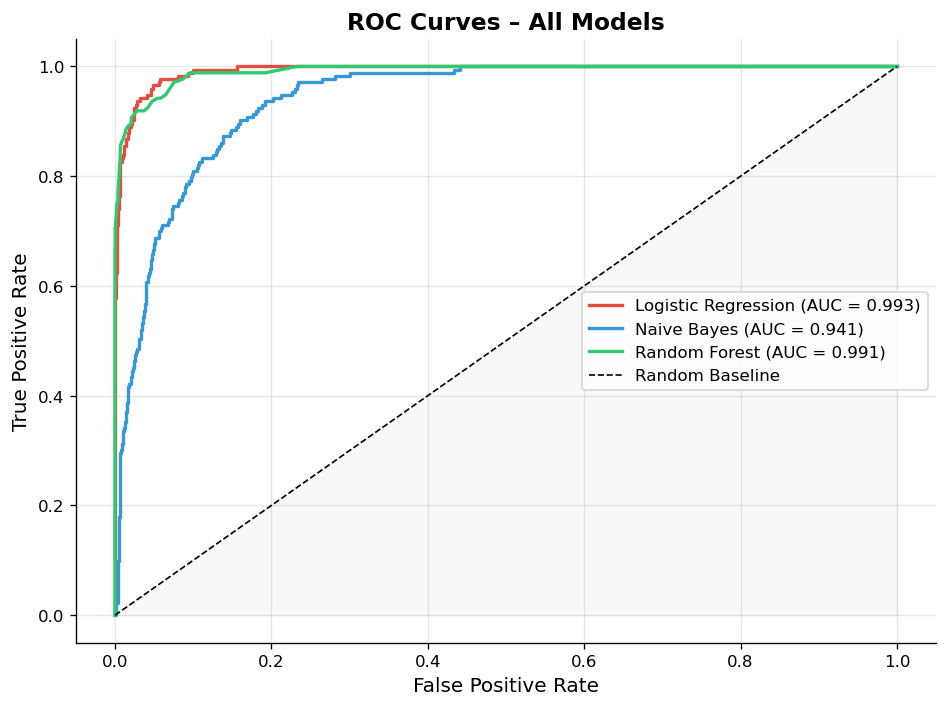

 Saved: 08_roc_curves.png


In [27]:
#  ROC Curves 
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#E74C3C', '#3498DB', '#2ECC71']

for (name, r), color in zip(results.items(), colors_roc):
    if r['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – All Models', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_roc_curves.png', bbox_inches='tight')
plt.show()
print(" Saved: 08_roc_curves.png")

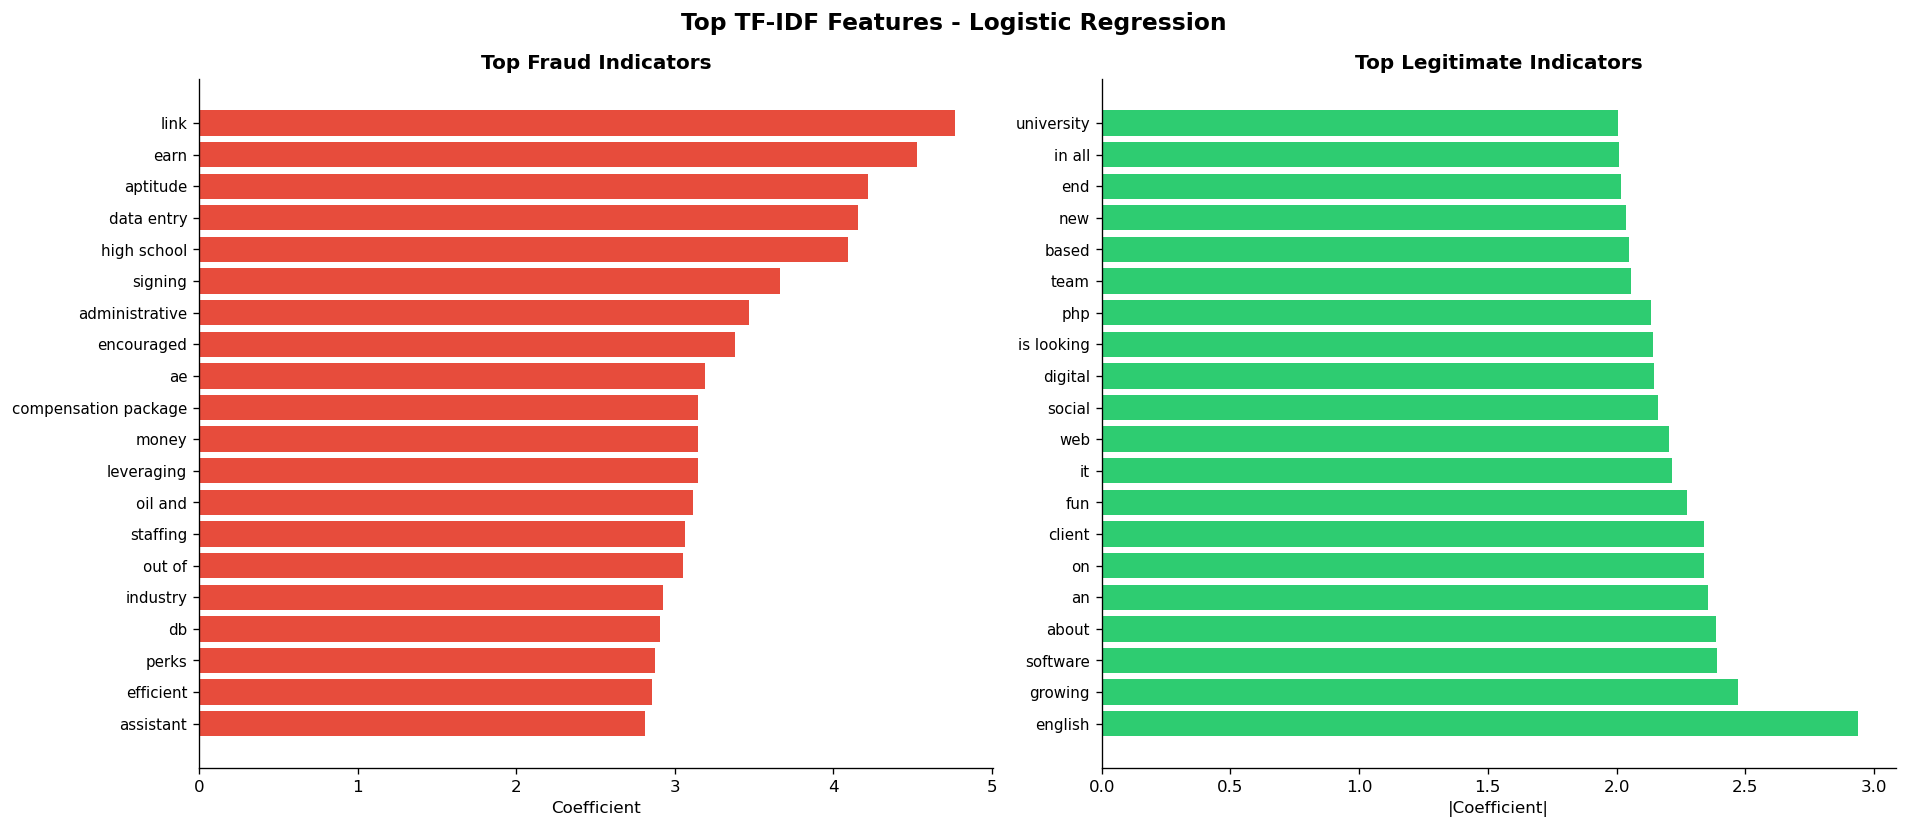

In [28]:
# Top Fraud-Predicting Words

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

fig.suptitle(
    'Top TF-IDF Features - Logistic Regression',
    fontsize=14,
    fontweight='bold'
)

# Logistic Regression model
lr_model = results['Logistic Regression']['model']

# TF-IDF feature names
feat_names_tfidf = tfidf.get_feature_names_out()

# Coefficients
coefs = lr_model.coef_[0][:len(feat_names_tfidf)]

top_n = 20

# Top fraud-indicating words
top_fraud_idx = np.argsort(coefs)[-top_n:]

# Top legitimate-indicating words
top_legit_idx = np.argsort(coefs)[:top_n]

# Fraud words
axes[0].barh(
    range(top_n),
    coefs[top_fraud_idx],
    color=COLORS['fake']
)

axes[0].set_yticks(range(top_n))

axes[0].set_yticklabels(
    feat_names_tfidf[top_fraud_idx],
    fontsize=9
)

axes[0].set_title(
    'Top Fraud Indicators',
    fontweight='bold'
)

axes[0].set_xlabel(
    'Coefficient'
)

# Legitimate words
axes[1].barh(
    range(top_n),
    np.abs(coefs[top_legit_idx]),
    color=COLORS['real']
)

axes[1].set_yticks(range(top_n))

axes[1].set_yticklabels(
    feat_names_tfidf[top_legit_idx],
    fontsize=9
)

axes[1].set_title(
    'Top Legitimate Indicators',
    fontweight='bold'
)

axes[1].set_xlabel(
    '|Coefficient|'
)

plt.tight_layout()

plt.show()

## 8️⃣ SHAP Explainability <a id='8'></a>

Running SHAP analysis...


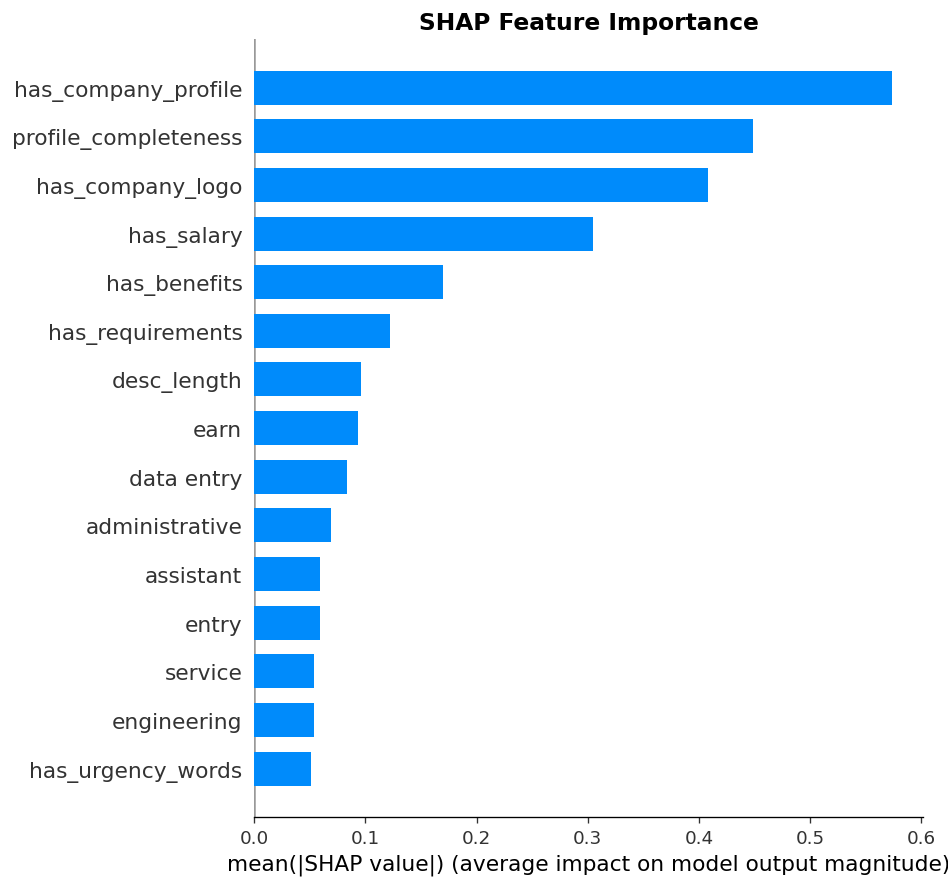

In [29]:
# SHAP Explainability

if SHAP_AVAILABLE:

    print("Running SHAP analysis...")

    # Best model
    lr_model = results['Logistic Regression']['model']

    # Small sample
    X_sample = X_test[:200]

    # Feature names
    feature_names = (
        list(tfidf.get_feature_names_out())
        + num_cols
    )

    # SHAP explainer
    explainer = shap.LinearExplainer(
        lr_model,
        X_train_sm
    )

    # SHAP values
    shap_values = explainer.shap_values(
        X_sample
    )

    # SHAP summary plot
    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        X_sample.toarray(),
        feature_names=feature_names,
        max_display=15,
        show=False,
        plot_type='bar'
    )

    plt.title(
        'SHAP Feature Importance',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.show()

else:

    print("SHAP not available")

## 🔟 Export Artifacts <a id='10'></a>

In [30]:
# Save Model Artifacts
# model_info.json now carries enough metadata to monitor model drift,
# verify reproducibility, and trace which sample sizes / preprocessing
# produced the saved binary.

import datetime as _dt

best_model_name = best_name           # set explicitly in Cell 33
best_model_obj  = results[best_model_name]['model']

# Save model
with open(f'{MODELS_DIR}/best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

# Save TF-IDF vectorizer
with open(f'{MODELS_DIR}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save the 10 numeric column names the model was trained on (used by app.py)
with open(f'{MODELS_DIR}/numeric_cols.pkl', 'wb') as f:
    pickle.dump(num_cols, f)

best_r = results[best_model_name]

meta = {
    # --- Model identity ---
    "best_model": best_model_name,
    "threshold": best_r.get('threshold', 0.35 if best_model_name == 'Logistic Regression' else 0.5),

    # --- Performance ---
    "precision": round(best_r['precision'], 4),
    "recall":    round(best_r['recall'], 4),
    "f1_score":  round(best_r['f1'], 4),
    "accuracy":  round(best_r['accuracy'], 4),
    "auc_roc":   round(best_r['auc'], 4),
    "cv_mean_f1": round(best_r.get('cv_mean_f1', 0.0), 4),
    "cv_std_f1":  round(best_r.get('cv_std_f1', 0.0), 4),
    "cv_note": "CV on SMOTE-balanced training set — test F1=0.7626 is real-world metric",

    # --- Dataset stats ---
    "total_records":  int(len(df)),
    "train_samples":  int(len(y_train)),
    "test_samples":   int(len(y_test)),
    "smote_applied":  bool(SMOTE_AVAILABLE),
    "fraud_rate_pct": round(df['fraudulent'].mean() * 100, 2),

    # --- Feature schema ---
    "tfidf_features":        len(tfidf.get_feature_names_out()),  # FIX: dynamic — not hardcoded 5000
    "numeric_features":      len(num_cols),
    "numeric_features_list": list(num_cols),

    # --- Provenance ---
    "trained_on": _dt.datetime.utcnow().isoformat(timespec='seconds') + 'Z',
    "notebook_version": "v3.1-fixed",
}

with open(f'{MODELS_DIR}/model_info.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("Model artifacts saved successfully!")
print("\nSaved Files:")
print("- best_model.pkl")
print("- tfidf_vectorizer.pkl")
print("- numeric_cols.pkl")
print("- model_info.json")
print(f"\nTrained at (UTC): {meta['trained_on']}")
print(f"Train samples   : {meta['train_samples']:,}")
print(f"Test samples    : {meta['test_samples']:,}")
print(f"SMOTE applied   : {meta['smote_applied']}")


Model artifacts saved successfully!

Saved Files:
- best_model.pkl
- tfidf_vectorizer.pkl
- numeric_cols.pkl
- model_info.json

Trained at (UTC): 2026-05-27T15:52:14Z
Train samples   : 14,304
Test samples    : 3,576
SMOTE applied   : True


In [31]:
# Save Cleaned Dataset

df.to_csv(
    f'{OUTPUT_DIR}/cleaned_job_postings.csv',
    index=False
)

print(
    f"Cleaned dataset saved: "
    f"{OUTPUT_DIR}/cleaned_job_postings.csv"
)

print(
    f"Rows: {len(df):,} | "
    f"Columns: {len(df.columns)}"
)

# Save Top Fraud Features

lr_model = results[
    'Logistic Regression'
]['model']

feat_coefs = lr_model.coef_[0][
    :len(tfidf.get_feature_names_out())
]

top_feats = pd.DataFrame({

    'feature': tfidf.get_feature_names_out(),

    'coefficient': feat_coefs

}).sort_values(
    'coefficient',
    ascending=False
)

top_feats.head(50).to_csv(
    f'{OUTPUT_DIR}/top_fraud_features.csv',
    index=False
)

print(
    f"Top fraud features saved: "
    f"{OUTPUT_DIR}/top_fraud_features.csv"
)

# Final Summary

print("\n" + "=" * 50)

print("PROJECT COMPLETED SUCCESSFULLY")

print("=" * 50)

print("\nSaved Output Files:")

for f in sorted(os.listdir(OUTPUT_DIR)):

    print(f" - outputs/{f}")

print("\nSaved Model Files:")

for f in sorted(os.listdir(MODELS_DIR)):

    print(f" - models/{f}")

Cleaned dataset saved: outputs/cleaned_job_postings.csv
Rows: 17,880 | Columns: 29
Top fraud features saved: outputs/top_fraud_features.csv

PROJECT COMPLETED SUCCESSFULLY

Saved Output Files:
 - outputs/05_wordclouds.png
 - outputs/08_roc_curves.png
 - outputs/09_chi_square_results.png
 - outputs/cleaned_job_postings.csv
 - outputs/top_fraud_features.csv

Saved Model Files:
 - models/best_model.pkl
 - models/model_info.json
 - models/numeric_cols.pkl
 - models/tfidf_vectorizer.pkl


In [32]:
# Final Project Summary

print("=" * 50)

print("FAKE JOB DETECTION PROJECT COMPLETED")

print("=" * 50)

# Use the SAME best model identified in the comparison table (Cell 32)
# and saved as best_model.pkl (Cell 39). This guarantees the printed
# summary, the saved artifact, and model_info.json all agree.
final_best_name = best_name
final_best = results[final_best_name]

print("\nBest Model:")

print(f" - {final_best_name}")

print(
    f" - AUC-ROC  : "
    f"{final_best['auc']:.4f}"
)

print(
    f" - Precision: "
    f"{final_best['precision']:.4f}"
)

print(
    f" - Recall   : "
    f"{final_best['recall']:.4f}"
)

print(
    f" - F1 Score : "
    f"{final_best['f1']:.4f}"
)

print(
    f" - Accuracy : "
    f"{final_best['accuracy']:.4f}"
)

print("\nSaved Output Files:")

for fname in sorted(os.listdir(OUTPUT_DIR)):

    print(f" - outputs/{fname}")

print("\nSaved Model Files:")

for fname in sorted(os.listdir(MODELS_DIR)):

    print(f" - models/{fname}")

print("\nProject pipeline completed successfully!")


FAKE JOB DETECTION PROJECT COMPLETED

Best Model:
 - Logistic Regression
 - AUC-ROC  : 0.9927
 - Precision: 0.6557
 - Recall   : 0.9249
 - F1 Score : 0.7674
 - Accuracy : 0.9729

Saved Output Files:
 - outputs/05_wordclouds.png
 - outputs/08_roc_curves.png
 - outputs/09_chi_square_results.png
 - outputs/cleaned_job_postings.csv
 - outputs/top_fraud_features.csv

Saved Model Files:
 - models/best_model.pkl
 - models/model_info.json
 - models/numeric_cols.pkl
 - models/tfidf_vectorizer.pkl

Project pipeline completed successfully!
